# **Inadimplência de clientes de cartão de crédito**

-   [Inadimplência de clientes de cartão de crédito](https://www.kaggle.com/datasets/gabrieloliveirasan/inadimplncia-de-clientes-de-carto-de-crdito?resource=download)





In [1]:
%%capture 
# Atualização da biblioteca Plotly
!pip install --upgrade plotly

In [2]:
# Importação das bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# Montar drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Importando a base de transações de cartão de crédito e armazenando na variável df_inadimplencia.
# Nessa carga, as linhas linhas 'na' foram consideradas como nulas.
df_inadimplencia = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/puc-minas/trabalho final/credito.csv', na_values = 'na')

In [5]:
# Função head para retornar as primeiras n linhas do Dataset.
df_inadimplencia.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28


In [6]:
# Análise dos tipos das colunas do dataset.
df_inadimplencia.dtypes

id                          int64
default                     int64
idade                       int64
sexo                       object
dependentes                 int64
escolaridade               object
estado_civil               object
salario_anual              object
tipo_cartao                object
meses_de_relacionamento     int64
qtd_produtos                int64
iteracoes_12m               int64
meses_inativo_12m           int64
limite_credito             object
valor_transacoes_12m       object
qtd_transacoes_12m          int64
dtype: object

In [7]:
# Soma da quantidade de valores nulos.
df_inadimplencia.isnull().sum()

id                            0
default                       0
idade                         0
sexo                          0
dependentes                   0
escolaridade               1519
estado_civil                749
salario_anual              1112
tipo_cartao                   0
meses_de_relacionamento       0
qtd_produtos                  0
iteracoes_12m                 0
meses_inativo_12m             0
limite_credito                0
valor_transacoes_12m          0
qtd_transacoes_12m            0
dtype: int64

**A partir das análises acima, temos dados nulos nos campos "escolaridade", "estado_civil" e "salario_anual".**

In [8]:
# Quantidade de linhas e colunas deste dataframe.
df_inadimplencia.shape

(10127, 16)

In [9]:
# Retorna o dataframe com linhas duplicadas removidas.
df_inadimplencia.drop_duplicates()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,0,50,M,2,mestrado,solteiro,$40K - $60K,blue,40,3,3,2,"4.003,91","15.476,26",117
10123,710638233,1,41,M,2,NaN,divorciado,$40K - $60K,blue,25,4,3,2,"4.277,04","8.764,88",69
10124,716506083,1,44,F,1,ensino medio,casado,menos que $40K,blue,36,5,4,3,"5.409,16","10.291,78",60
10125,717406983,1,30,M,2,mestrado,NaN,$40K - $60K,blue,36,4,3,3,"5.281,84","8.395,62",62


In [10]:
# Análise de registros duplicados após o comando drop_duplicates().
df_inadimplencia[df_inadimplencia.isnull().any(axis=1)]

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
6,810347208,0,51,M,4,NaN,casado,$120K +,gold,46,6,3,1,"34.516,72","1.330,87",31
7,818906208,0,32,M,0,ensino medio,NaN,$60K - $80K,silver,27,2,2,2,"29.081,49","1.538,32",36
10,708790833,0,42,M,5,sem educacao formal,NaN,$120K +,blue,31,5,2,3,"6.748,40","1.201,27",42
11,710821833,0,65,M,1,NaN,casado,$40K - $60K,blue,54,6,3,2,"9.095,59","1.314,42",26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10101,718372458,0,42,M,2,mestrado,NaN,$40K - $60K,blue,30,3,5,2,"3.735,34","14.501,92",92
10118,713755458,1,50,M,1,NaN,NaN,$80K - $120K,blue,36,6,4,3,"9.959,96","10.310,41",63
10119,716893683,1,55,F,3,sem educacao formal,solteiro,NaN,blue,47,4,3,3,"14.657,85","6.009,18",53
10123,710638233,1,41,M,2,NaN,divorciado,$40K - $60K,blue,25,4,3,2,"4.277,04","8.764,88",69


**Não identificamos registros duplicados.**


# **Tratando a nossa base de dados (df_inadimplencia_edit)** 

**Remoção de colunas**

In [11]:
# em um novo dataframe, removemos das colunas "id", "sexo" e "escolaridade". Colunas que não serão utilizadas no nosso modelo
df_inadimplencia_edit = df_inadimplencia.drop(['id','sexo','escolaridade'], axis=1)

In [12]:
# Verificação de dados nulos. 
df_inadimplencia_edit[df_inadimplencia_edit.isnull().any(axis=1)]

,default,idade,dependentes,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
3,0,40,4,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
7,0,32,0,NaN,$60K - $80K,silver,27,2,2,2,"29.081,49","1.538,32",36
10,0,42,5,NaN,$120K +,blue,31,5,2,3,"6.748,40","1.201,27",42
13,0,35,3,NaN,$60K - $80K,blue,30,5,3,1,"8.547,74","1.311,48",33
15,0,44,4,NaN,$80K - $120K,blue,37,5,2,1,"4.234,96","1.348,10",27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10100,0,39,2,NaN,$60K - $80K,silver,36,4,2,2,"29.808,17","16.098,13",128
10101,0,42,2,NaN,$40K - $60K,blue,30,3,5,2,"3.735,34","14.501,92",92
10118,1,50,1,NaN,$80K - $120K,blue,36,6,4,3,"9.959,96","10.310,41",63
10119,1,55,3,solteiro,NaN,blue,47,4,3,3,"14.657,85","6.009,18",53


*O Dataset apresentou um valor que consideramos auto. Em 17%*

In [13]:
# Quantidade de registros nulos por coluna
df_inadimplencia_edit.isnull().sum()

default                       0
idade                         0
dependentes                   0
estado_civil                749
salario_anual              1112
tipo_cartao                   0
meses_de_relacionamento       0
qtd_produtos                  0
iteracoes_12m                 0
meses_inativo_12m             0
limite_credito                0
valor_transacoes_12m          0
qtd_transacoes_12m            0
dtype: int64

In [14]:
# Análise descritiva 
df_inadimplencia_edit.select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.0,0.0,0.0,0.0,1.0
idade,10127.0,46.325960,8.016814,26.0,41.0,46.0,52.0,73.0
dependentes,10127.0,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,10127.0,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0
qtd_produtos,10127.0,3.812580,1.554408,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,10127.0,2.455317,1.106225,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,10127.0,2.341167,1.010622,0.0,2.0,2.0,3.0,6.0
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0


*Identificamos que a média de idade dos clientes são na sua maioria de 46 anos o ou menos.*

In [15]:
# Verificar dados que temos na coluna Salario_anual.
df_inadimplencia_edit['salario_anual'].unique()

array(['$60K - $80K', 'menos que $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', nan], dtype=object)

**Vamos usar a moda para os dados de "60K− 80K" para os dados nulos do campo "salario_anual".**

In [16]:
# Substituimos os dados nulos da coluna "Salario_anual" pela moda.
df_inadimplencia_edit['salario_anual'].fillna('$60K - $80K',inplace=True)

In [17]:
# Consultar os dados únicos.
df_inadimplencia_edit['salario_anual'].unique()

array(['$60K - $80K', 'menos que $40K', '$80K - $120K', '$40K - $60K',
       '$120K +'], dtype=object)

In [18]:
# Quantidade de registros nulos por coluna
df_inadimplencia_edit.isnull().sum()

default                      0
idade                        0
dependentes                  0
estado_civil               749
salario_anual                0
tipo_cartao                  0
meses_de_relacionamento      0
qtd_produtos                 0
iteracoes_12m                0
meses_inativo_12m            0
limite_credito               0
valor_transacoes_12m         0
qtd_transacoes_12m           0
dtype: int64

In [19]:
# Ainda existem dados nulos na coluna estado_civil, cerca de 7,4%
df_inadimplencia_edit[df_inadimplencia_edit.isnull().any(axis=1)]

,default,idade,dependentes,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
3,0,40,4,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
7,0,32,0,NaN,$60K - $80K,silver,27,2,2,2,"29.081,49","1.538,32",36
10,0,42,5,NaN,$120K +,blue,31,5,2,3,"6.748,40","1.201,27",42
13,0,35,3,NaN,$60K - $80K,blue,30,5,3,1,"8.547,74","1.311,48",33
15,0,44,4,NaN,$80K - $120K,blue,37,5,2,1,"4.234,96","1.348,10",27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10070,0,47,3,NaN,$80K - $120K,silver,40,5,2,3,"34.516,36","15.930,54",123
10100,0,39,2,NaN,$60K - $80K,silver,36,4,2,2,"29.808,17","16.098,13",128
10101,0,42,2,NaN,$40K - $60K,blue,30,3,5,2,"3.735,34","14.501,92",92
10118,1,50,1,NaN,$80K - $120K,blue,36,6,4,3,"9.959,96","10.310,41",63


In [20]:
# Retirada dos dados nulos da coluna estado_civil. 
df_inadimplencia_edit.dropna(inplace=True)

In [21]:
# Verificação de registros nulos por coluna
df_inadimplencia_edit.isnull().sum()

default                    0
idade                      0
dependentes                0
estado_civil               0
salario_anual              0
tipo_cartao                0
meses_de_relacionamento    0
qtd_produtos               0
iteracoes_12m              0
meses_inativo_12m          0
limite_credito             0
valor_transacoes_12m       0
qtd_transacoes_12m         0
dtype: int64

In [22]:
# Alteração da coluna limite_credito para float
df_inadimplencia_edit['limite_credito'] = df_inadimplencia_edit['limite_credito'].apply(lambda valor: float(valor.replace(".", "").replace(",", ".")))

In [23]:
# Alteração da coluna valor_transacoes_12m para float
df_inadimplencia_edit['valor_transacoes_12m'] = df_inadimplencia_edit['valor_transacoes_12m'].apply(lambda valor: float(valor.replace(".", "").replace(",", ".")))

In [24]:
# Quantidade de cada tipo_cartão
df_inadimplencia_edit['tipo_cartao'].value_counts()

blue        8753
silver       503
gold         104
platinum      18
Name: tipo_cartao, dtype: int64

**Tratamento dos dados da coluna Salario_anual**

In [25]:
# Função que altera os dados "strings" para dados numéricos.
def transf_salario (salario):
    if salario == 'menos que $40K':
        return 1
    elif salario == '$40K - $60K':
        return 2
    elif salario == '$60K - $80K':
        return 3
    elif salario == '$80K - $120K':
        return 4
    elif salario == '$120K +':
        return 5

In [26]:
# Alteração do campo salario_anual com a função transf_salario().
df_inadimplencia_edit['salario_anual'] = df_inadimplencia_edit['salario_anual'].apply(transf_salario)

In [27]:
# Consulta os dados únicos na coluna "salario_anual"
df_inadimplencia_edit['salario_anual'].unique()

array([3, 1, 4, 2, 5])

**Tratamento dos dados da coluna Estado_civil**

In [28]:
# Consulta os dados únicos na coluna "estado_civil"
df_inadimplencia_edit['estado_civil'].unique()

array(['casado', 'solteiro', 'divorciado'], dtype=object)

In [29]:
# Função que altera os dados "strings" para dados numéricos.
def transf_civil (civil):
    if civil == 'solteiro':
        return 1
    elif civil == 'casado':
        return 2
    elif civil == 'divorciado':
        return 3

In [30]:
# Alteração do campo "estado_civil" para numérico.
df_inadimplencia_edit['estado_civil'] = df_inadimplencia_edit['estado_civil'].apply(transf_civil)
df_inadimplencia_edit['estado_civil'].unique()

array([2, 1, 3])

**Tratamento dos dados da coluna Meses_de_relacionamento**

In [31]:
df_inadimplencia_edit['meses_de_relacionamento'].max()

56

In [32]:
# Função que altera os dados da coluna meses_de_relacionamento em intervalos
def transf_meses (meses):
    if meses >=12 and meses <24:
        return 1
    elif meses >= 24 and meses <36:
        return 2
    elif meses >= 36 and meses <48:
        return 3
    elif meses >=48 and meses <60:
        return 4


In [33]:
# Aplicar a função trans_meses
df_inadimplencia_edit['meses_de_relacionamento'] = df_inadimplencia_edit['meses_de_relacionamento'].apply(transf_meses)
df_inadimplencia_edit['meses_de_relacionamento'].unique()

array([3, 1, 4, 2])

In [34]:
# Consultar os dados únicos da coluna "idade".
df_inadimplencia_edit['idade'].unique()

array([45, 49, 51, 40, 44, 37, 48, 65, 56, 57, 41, 61, 47, 62, 54, 63, 53,
       58, 55, 42, 66, 50, 38, 59, 46, 52, 39, 43, 64, 68, 67, 60, 73, 70,
       35, 36, 34, 33, 26, 31, 32, 29, 30, 28, 27])

**Tratamento dos dados da coluna Idade**

In [35]:
# Função que altera os dados da coluna idade em intervalos.
def transf_idade (idade):
    if idade >=18 and idade <29:
        return 1
    elif idade >= 29 and idade <40:
        return 2
    elif idade >= 40 and idade <50:
        return 3
    elif idade >=50 and idade <60:
        return 4
    elif idade >=60 :
        return 5

In [36]:
# Aplicar a função idade na coluna "idade".
df_inadimplencia_edit['idade'] = df_inadimplencia_edit['idade'].apply(transf_idade)
df_inadimplencia_edit['idade'].unique()

array([3, 4, 2, 5, 1])

**Tratamento dos dados da coluna Limite_credito**

In [37]:
# Verificar o tamanho da coluna "limite_credito"
len(df_inadimplencia_edit['limite_credito'].unique())

8603

In [38]:
# Consultar o limite máximo de crédito dentro da coluna "limitee_credito"
df_inadimplencia_edit['limite_credito'].max()

34516.99

In [39]:
# Função que altera os dados da coluna idade em intervalos
def transf_limite (limite):
    if limite >=0 and limite <5000:
        return 1
    elif limite >= 5000 and limite <10000:
        return 2
    elif limite >= 10000 and limite <15000:
        return 3
    elif limite >=15000 and limite <20000:
        return 4
    elif limite >=20000 and limite <25000:
        return 5
    elif limite >=25000 and limite <30000:
        return 6
    elif limite >=30000:
        return 7


In [40]:
# Aplicar a função transf_limite que classifica a coluna idade.
df_inadimplencia_edit['limite_credito'] = df_inadimplencia_edit['limite_credito'].apply(transf_limite)
df_inadimplencia_edit['limite_credito'].unique()

array([3, 2, 1, 7, 5, 4, 6])

**Tratamento dos dados da coluna valor_transacoes_12m**

In [41]:
# Verificar o valor máximo de transição.
df_inadimplencia_edit['valor_transacoes_12m'].max()

18484.93

In [42]:
# Função que altera os dados da coluna idade em intervalos
def transf_transacao (transacao):
    if transacao >=0 and transacao <5000:
        return 1
    elif transacao >= 5000 and transacao <10000:
        return 2
    elif transacao >= 10000 and transacao <15000:
        return 3
    elif transacao >= 15000:
        return 4


In [43]:
# Aplicar a função trans_transacao.
df_inadimplencia_edit['valor_transacoes_12m'] = df_inadimplencia_edit['valor_transacoes_12m'].apply(transf_transacao)
df_inadimplencia_edit['valor_transacoes_12m'].unique()

array([1, 2, 3, 4])

**Tratamento dos dados da coluna qtd_transacoes_12m**

In [44]:
# Verificar o valor máximmo de transação em um período de 12 meses.
df_inadimplencia_edit['qtd_transacoes_12m'].max()

139

In [45]:
# Função que altera os dados da coluna idade em intervalos
def transf_transacoes (transacoes):
    if transacoes >=0 and transacoes <40:
        return 1
    elif transacoes >= 40 and transacoes <80:
        return 2
    elif transacoes >= 80 and transacoes <120:
        return 3
    elif transacoes  >= 120:
        return 4


In [46]:
# Aplicar a função transf_transacoes() e salvar dentro do dataframe.
df_inadimplencia_edit['qtd_transacoes_12m'] = df_inadimplencia_edit['qtd_transacoes_12m'].apply(transf_transacoes)
df_inadimplencia_edit['qtd_transacoes_12m'].unique()

array([2, 1, 3, 4])

In [47]:
# Consultar valores únicos.
df_inadimplencia_edit['qtd_transacoes_12m'].unique()

array([2, 1, 3, 4])

In [48]:
# Análise descritiva após tratamentos dos dados
df_inadimplencia_edit.select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,9378.0,0.159736,0.366380,0.0,0.0,0.0,0.0,1.0
idade,9378.0,3.193645,0.853597,1.0,3.0,3.0,4.0,5.0
dependentes,9378.0,2.330881,1.300375,0.0,1.0,2.0,3.0,5.0
estado_civil,9378.0,1.659309,0.619826,1.0,1.0,2.0,2.0,3.0
salario_anual,9378.0,2.411282,1.296861,1.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,9378.0,2.641821,0.730210,1.0,2.0,3.0,3.0,4.0
qtd_produtos,9378.0,3.816699,1.548543,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,9378.0,2.458307,1.109462,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,9378.0,2.342610,1.008347,0.0,2.0,2.0,3.0,6.0
limite_credito,9378.0,2.188740,1.761930,1.0,1.0,1.0,3.0,7.0


*A idade mínima deste dataset é de 26 anos e a idade máxima é de 73 anos. Temos famílias de até 5 filhos. O mínimo observado de relacionamento com é de 13 meses e temos o máximo de até 6 produtos. O limite mínimo de crédito é de R\$ 1.438,00 e um valor de R\$ 34.516,99 de crédito máximo.*

# **VISUALIZAÇÕES**

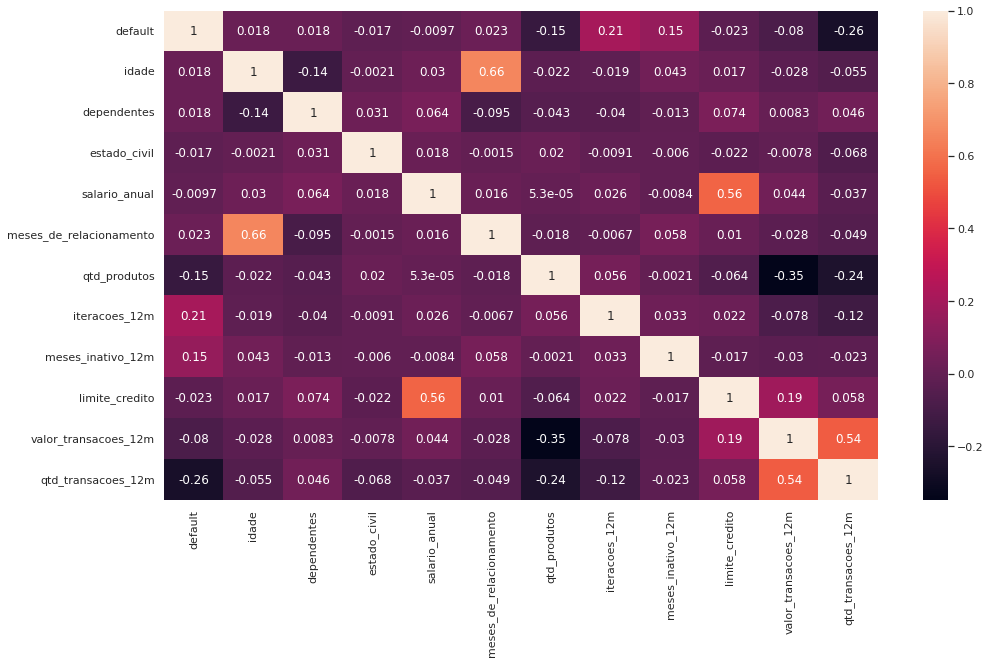

In [49]:
# Análise de correlação entre os dados. 
# Observação: não entra nesta análise os dados do tipo de cartão de crédito.
corr = df_inadimplencia_edit.corr()
# aumentar o tamanho da figura do método.
sns.set(rc={'figure.figsize':(16,9)}) 
sns.heatmap(corr, annot=True)

*Verificamos algumas correlações entre alguns dados. Forte correlação entre a coluna "qtd_transacoes_12m" e "valor_transacoes_12m". Além desta correlação, há uma correlação significativa entre "salario_anual" e "limite_credito", e ainda temos mais uma outra entre "idade" e "meses_de_relacionamento".*

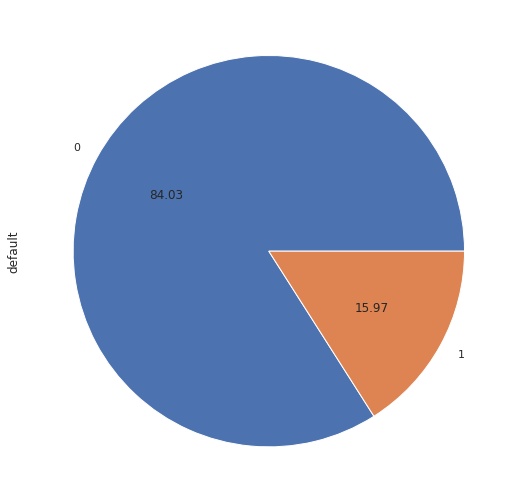

In [50]:
# Gráfico de pizza evidenciando que temos uma quantidade maior de pessoas adimplentes em porcentagem.
df_inadimplencia_edit['default'].value_counts().plot.pie(autopct='%.2f');

In [51]:
# Maior incidências de inadimplentes se dá a partir do 3 mês. 
Processo = df_inadimplencia_edit[['meses_de_relacionamento','default']].groupby(['meses_de_relacionamento','default']).size().reset_index(name='Value')
fig = px.line(Processo, x="meses_de_relacionamento", y="Value", color="default", 
            line_shape="spline", render_mode="svg",title='Adimplência')
fig.show()

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



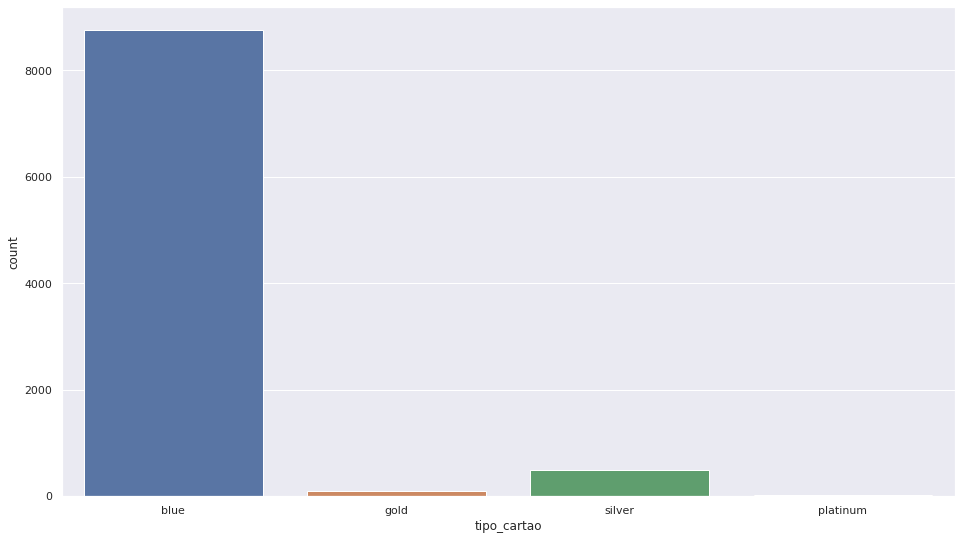

In [52]:
# Gráfico de tipo_cartao, evidenciando que temos uma quantidae maior do blue.
Tipo_cartao = sns.countplot(df_inadimplencia_edit['tipo_cartao'])

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



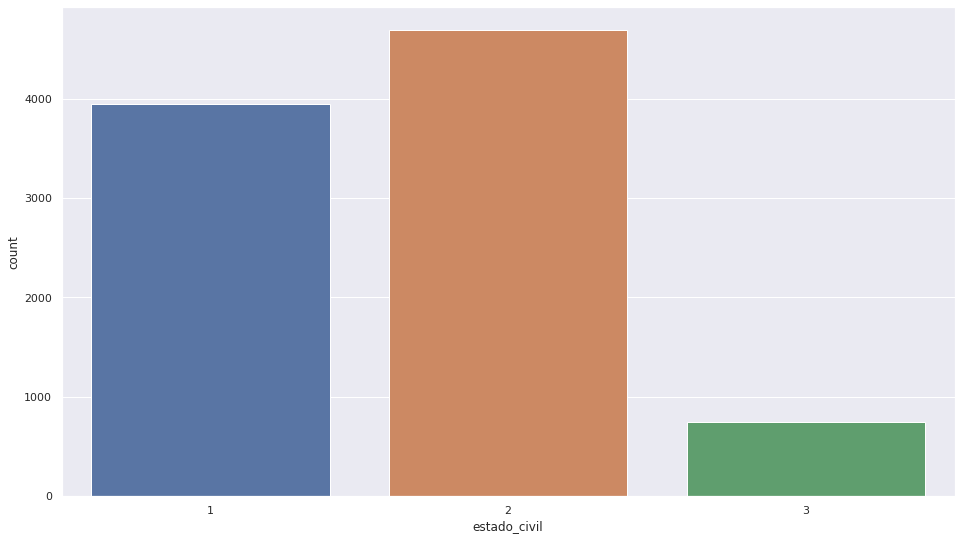

In [53]:
# Gráfico evidenciando a quantidade de clientes por estado civil.
estado_civil = sns.countplot(df_inadimplencia_edit['estado_civil'])

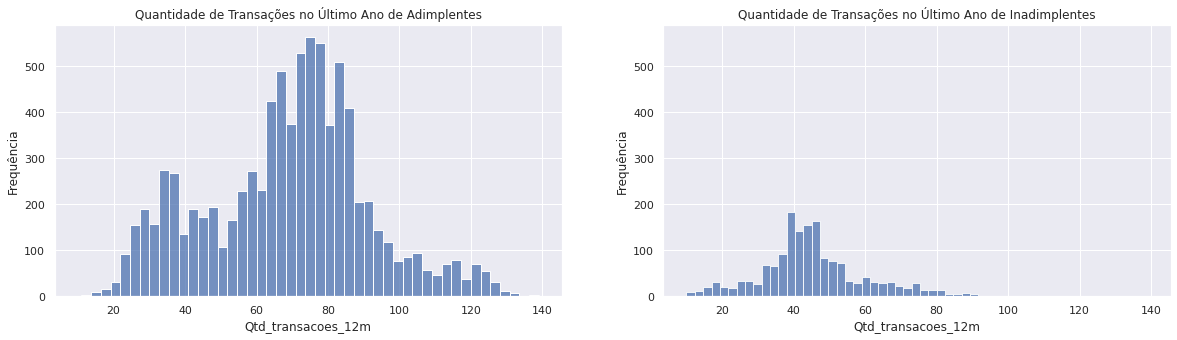

In [54]:
# Quantidade de transações no último ano entre as 3 bases (1ª base full, 2ª base com adimplentes e 3ª base com inadimplentes)
total_adimplentes = df_inadimplencia[df_inadimplencia['default'] == 0]
total_inadimplentes = df_inadimplencia[df_inadimplencia['default'] == 1]

coluna = 'qtd_transacoes_12m'
titulos = ['Quantidade de Transações no Último Ano de Adimplentes', 'Quantidade de Transações no Último Ano de Inadimplentes']

eixo = 0
max_y = 0 
figura, eixos = plt.subplots(1,2, figsize=(20, 5), sharex=True)

for dataframe in [ total_adimplentes, total_inadimplentes]:

  f = sns.histplot(x=coluna, data=dataframe, stat='count', ax=eixos[eixo]) 
  f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência')

  _, max_y_f = f.get_ylim()
  max_y = max_y_f if max_y_f > max_y else max_y
  f.set(ylim=(0, max_y))

  eixo += 1

figura.show()

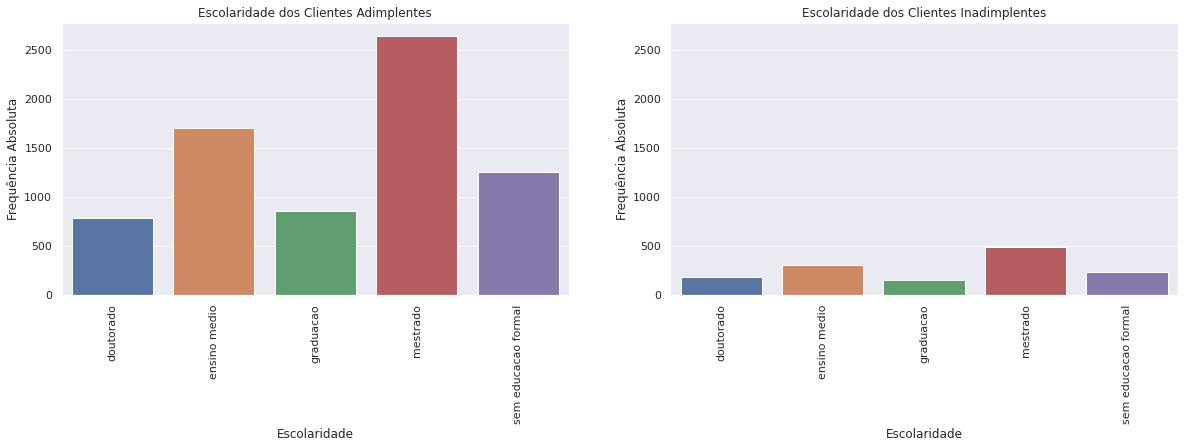

In [55]:
coluna = 'escolaridade'
titulos = ['Escolaridade dos Clientes Adimplentes', 'Escolaridade dos Clientes Inadimplentes']

eixo = 0
max_y = 0
max = df_inadimplencia.select_dtypes('object').describe()[coluna]['freq'] * 1.1

figura, eixos = plt.subplots(1,2, figsize=(20, 5), sharex=True)

for dataframe in [total_adimplentes, total_inadimplentes]:

  df_to_plot = dataframe[coluna].value_counts().to_frame()
  df_to_plot.rename(columns={coluna: 'frequencia_absoluta'}, inplace=True)
  df_to_plot[coluna] = df_to_plot.index
  df_to_plot.sort_values(by=[coluna], inplace=True)
  df_to_plot.sort_values(by=[coluna])

  f = sns.barplot(x=df_to_plot[coluna], y=df_to_plot['frequencia_absoluta'], ax=eixos[eixo])
  f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)

  _, max_y_f = f.get_ylim()
  max_y = max_y_f if max_y_f > max_y else max_y
  f.set(ylim=(0, max_y))

  eixo += 1

figura.show()

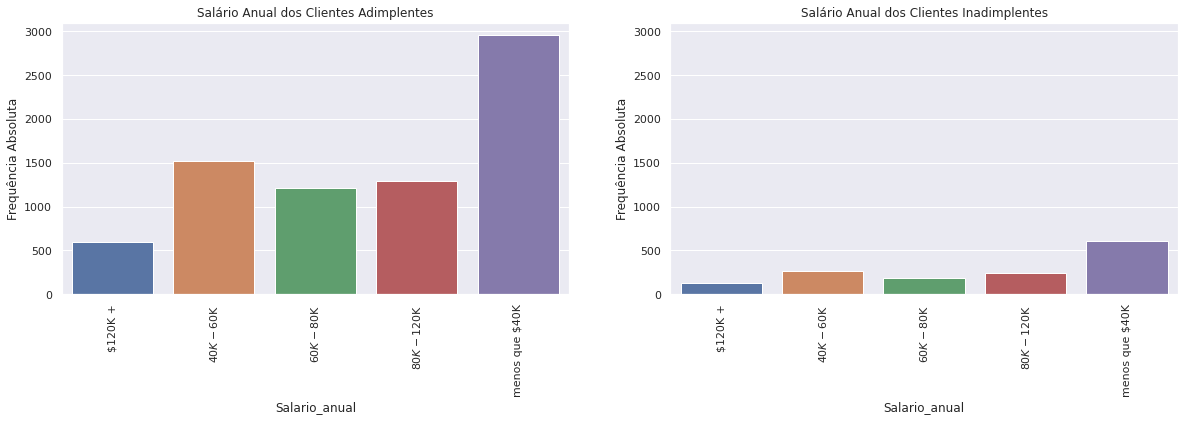

In [56]:
coluna = 'salario_anual'
titulos = [ 'Salário Anual dos Clientes Adimplentes', 'Salário Anual dos Clientes Inadimplentes']

eixo = 0
max_y = 0
figura, eixos = plt.subplots(1,2, figsize=(20, 5), sharex=True)

for dataframe in [ total_adimplentes,total_inadimplentes]:

  df_to_plot = dataframe[coluna].value_counts().to_frame()
  df_to_plot.rename(columns={coluna: 'frequencia_absoluta'}, inplace=True)
  df_to_plot[coluna] = df_to_plot.index
  df_to_plot.reset_index(inplace=True, drop=True)
  df_to_plot.sort_values(by=[coluna], inplace=True)

  f = sns.barplot(x=df_to_plot[coluna], y=df_to_plot['frequencia_absoluta'], ax=eixos[eixo])
  f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
  _, max_y_f = f.get_ylim()
  max_y = max_y_f if max_y_f > max_y else max_y
  f.set(ylim=(0, max_y))
  eixo += 1

figura.show()

# **Criação de modelos**

In [57]:
# Importação das bibliotecas

# Selecionar os dados em treino e teste
from sklearn.model_selection import train_test_split

# Modelo de regressão logística
from sklearn.linear_model import LogisticRegression

# Modelo de classificador de árvore de decisão
from sklearn.tree import DecisionTreeClassifier

#Essa função qualifica nossas métricas de desempenho e cálculos de distância.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
from sklearn import datasets, tree

In [58]:
# Separando em X e y
X = df_inadimplencia_edit.drop(['default','tipo_cartao'],axis=1)
y = df_inadimplencia_edit.default

In [59]:
# Fazendo a separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, 
                                                    random_state=42,stratify=y)

# Árvore de decisão (clfAD)


In [60]:
# Definindo o novo classificador
clfAD = DecisionTreeClassifier(random_state=0, max_depth=11)

In [61]:
# Fazendo o fit com os dados
clfAD = clfAD.fit(X_train,y_train)

In [62]:
# Fazendo a previsão
y_predAD = clfAD.predict(X_test)

In [63]:
# Gerando a matriz de confusão
confusion_matrix(y_test,y_predAD)

array([[2507,   94],
       [ 320,  174]])

Usando a **Matriz de Confusão**, foram identificados que:


*   2507 pessoas Adimplentes e que realmente o são.
*   320 dados de pessoas que também são adimplentes e que o modelo identificou como inadimplentes.
*   94 dados de pessoas inadimplentes que o modelo identificou como adimplentes e isto prejudica a instituição.
*   174 pessoas que o modelo identificou como inadimplentes.

In [64]:
# Calculando o recall
recall_score(y_test,y_predAD)

0.3522267206477733

In [65]:
# Calculando a acurácia
accuracy_score(y_test,y_predAD)

0.8662358642972536

In [66]:
# Calculando a precisão
precision_score(y_test,y_predAD)

0.6492537313432836

## Regressão Logistica (y_pred)

In [67]:
# Definindo o nosso classificador
clf = LogisticRegression(random_state=0,max_iter=500)

In [68]:
# Fazendo o fit dos dados
clf = clf.fit(X_train,y_train)

In [69]:
# E então fazer a previsão da nossa base de teste
y_pred = clf.predict(X_test)

In [70]:
# Avaliando a acurácia do modelo
accuracy_score(y_test,y_pred)

0.8630048465266559

In [71]:
# Visualizando a matriz de confusão
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[2537,   64],
       [ 360,  134]])

In [72]:
# E calculando o recall
recall_score(y_test,y_pred)

0.27125506072874495

## Visto que nosso modelo acima compromete a distribuição de forma que a matriz de confusão demonstra um alto erro em sua distribuição e que portanto, há a necessidade de balancear o dados. 

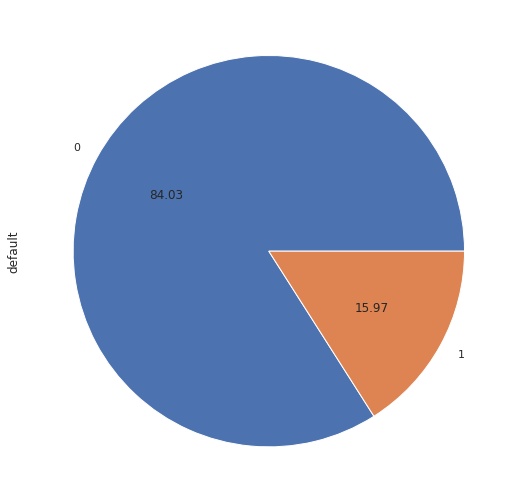

In [73]:
# Visualizando a proporção dessa base
y.value_counts().plot.pie(autopct='%.2f');

In [74]:
# Contando os valores em cada classe
y.value_counts()

0    7880
1    1498
Name: default, dtype: int64

In [75]:
# Verificando a proporção
(y.value_counts()/y.shape[0])*100

0    84.026445
1    15.973555
Name: default, dtype: float64

# **Considerando que precisa balancear os dados**

## Vimos que há um grande desbalanceamento dos dados. Conforme o gráfico abaixo, há mais de 84% de dados em favor dos adimplentes e isto cria um vies fortíssimo.



*   84% de pessoas adimplentes
*   16% de pessoas que estão inadimplentes



Balanceando o dataset
Temos 2 classes:
Classe majoritária: a que possui mais registros
Classe minoritária: a que possui menos registros
Podemos balancear o dataset reduzindo os registros da classe majoritária (com mais registros) ou aumentando os registros da classe minoritária (com menos registros)

Reduzindo os registros da classe majoritária
Vamos retirar dados da classe que possui mais registros
Precisamos ter cuidado para que essa retirada não acabe causando perda de informação (retirando informações que são muito importantes)
Também é necessário verificar o tamanho da base restante
Podemos começar fazendo isso excluindo registros de forma aleatória com o RandomUnderSampler

In [76]:
%%capture
# Instalando a biblioteca
!pip install -U imbalanced-learn

In [77]:
# Importando o RandomUnderSampler do imblearn
from imblearn.under_sampling import RandomUnderSampler

In [78]:
# Definindo o RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

In [79]:
# Aplicando para X e y
X_res, y_res = rus.fit_resample(X_train, y_train)

In [80]:
# Contando a quantidade de registros na base de treino
y_train.value_counts()

0    5279
1    1004
Name: default, dtype: int64

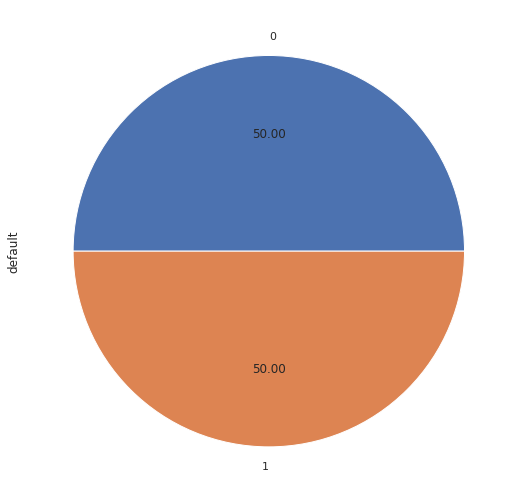

In [81]:
# # Visualizando graficamente
y_res.value_counts().plot.pie(autopct='%.2f');

In [82]:
# Contando os valores em cada classe
y_res.value_counts()

0    1004
1    1004
Name: default, dtype: int64

In [83]:
# Podemos usar novamente a Regressão Logística e verificar o resultado
clf2 = LogisticRegression(random_state=0,max_iter=500)
clf2 = clf2.fit(X_res, y_res)
y_pred2 = clf2.predict(X_test)

In [84]:
# Verificando o recall Regressão Logística
recall_score(y_test,y_pred2)

0.7388663967611336

In [85]:
#Precisão Regressão Logística
precision_score(y_test,y_pred2)

0.33091568449682685

In [86]:
# Gerando a matriz de confusão
confusion_matrix(y_test,y_pred2)

array([[1863,  738],
       [ 129,  365]])

In [87]:
# Utilizando a árvore de decisão
clfAD2 = DecisionTreeClassifier(random_state=0, max_depth=11)
clfAD2 = clfAD2.fit(X_res, y_res)
y_predAD2 = clfAD2.predict(X_test)

In [88]:
# Verificando o recall da árvore de decisão
recall_score(y_test,y_predAD2)

0.7368421052631579

In [89]:
precision_score(y_test,y_predAD2)

0.35135135135135137

In [90]:
# Gerando a matriz de confusão
confusion_matrix(y_test,y_predAD2)

array([[1929,  672],
       [ 130,  364]])

In [91]:
print("Acurácia de previsão:", accuracy_score(y_test,y_predAD2))

Acurácia de previsão: 0.7408723747980613


1929 pessoas foram classificadas corretamente como adimplentes                            
672 pessoas adimplentes foram classificadas erroneamente como inadimplentes                     
130 pessoa foi classificada erroneamente como adimplente                   
364 pessoas foram classificadas corretamente como inadimplentes

Aumentando os registros da classe minoritária
Duplicando os valores de maneira aleatória com o RandomOverSampler
Precisamos garantir que não vamos ter overfitting por mostrar ao modelo várias vezes os mesmos dados

In [92]:
# Importando o RandomOverSampler do imblearn
from imblearn.over_sampling import RandomOverSampler

In [93]:
# Instanciando
ros = RandomOverSampler(random_state=42)

In [94]:
# Aplicando para X e y
X_resROS, y_resROS = ros.fit_resample(X_train, y_train)

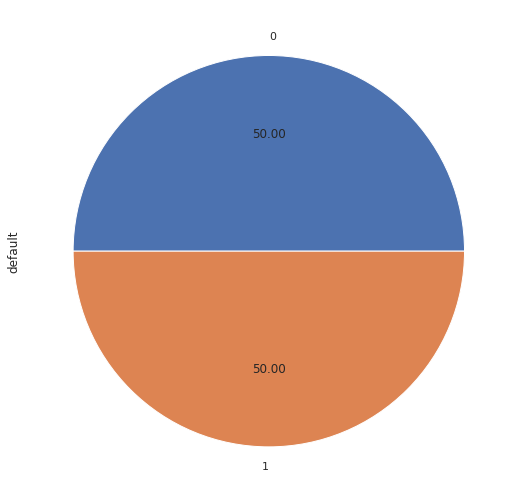

In [95]:
# Visualizando graficamente
y_resROS.value_counts().plot.pie(autopct='%.2f');

In [96]:
# Contando os valores em cada classe
y_resROS.value_counts()

0    5279
1    5279
Name: default, dtype: int64

In [97]:
# Usando novamente a regressão logística com os dados de oversampling
clf2 = LogisticRegression(random_state=0,max_iter=500)
clf2 = clf2.fit(X_resROS,y_resROS)
y_pred2 = clf2.predict(X_test)

In [98]:
# Verificando o recall regressão logística
recall_score(y_test,y_pred2)

0.7449392712550608

In [99]:
# Comparando a precisão dos 2 modelos Regressão
precision_score(y_test,y_pred2)

0.3318304779080252

In [100]:
#Gerando a matriz de confusão do modelo Regressão Logística
confusion_matrix(y_test,y_pred2)

array([[1860,  741],
       [ 126,  368]])

In [101]:
# Utilizando a árvore de decisão
clfAD2 = DecisionTreeClassifier(random_state=0, max_depth=11)
clfAD2 = clfAD2.fit(X_resROS,y_resROS)
y_predAD2 = clfAD2.predict(X_test)

# Imprime a profundidade da árvore
print(clfAD2.tree_.max_depth)

11


In [102]:
# Verificando o recall
recall_score(y_test,y_predAD2)

0.694331983805668

In [103]:
# Gerando a matriz de confusão do modelo Árvore de decisão
confusion_matrix(y_test,y_predAD2)

array([[1980,  621],
       [ 151,  343]])

In [104]:
print("Acurácia de previsão:", accuracy_score(y_test,y_predAD2))

Acurácia de previsão: 0.7505654281098546


In [105]:
# Comparando a precisão dos 2 modelos árvores de decisão
precision_score(y_test,y_predAD2)

0.3558091286307054

1980 pessoas foram classificadas corretamente como adimplentes    
621 pessoas adimplentes foram classificadas erroneamente como inadimplentes        
151 pessoa foi classificada erroneamente como adimplente                           
343 pessoas foram classificadas corretamente como inadimplentes


In [106]:
# Visualizando graficamente
import matplotlib.pyplot as plt

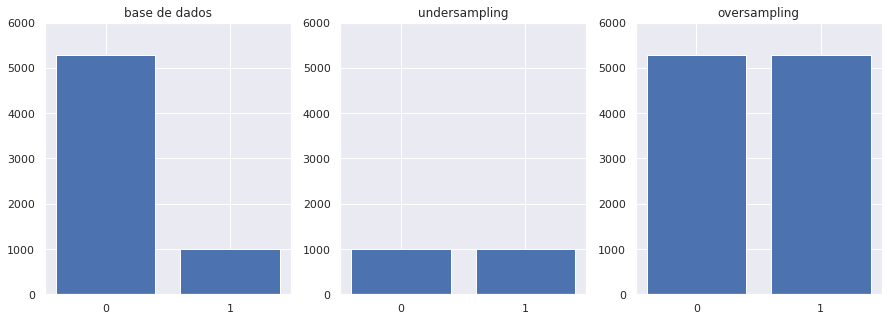

In [107]:
# Plotando os 3 gráficos de barra
fig,ax=plt.subplots(ncols=3,figsize=(15,5))

ax[0].bar(y_train.value_counts().index,y_train.value_counts().values)
ax[1].bar(y_res.value_counts().index,y_res.value_counts().values)
ax[2].bar(y_resROS.value_counts().index,y_resROS.value_counts().values)

ax[0].set(ylim=(0,6000),xticks=[0,1])
ax[0].set_title('base de dados')
ax[1].set(ylim=(0,6000),xticks=[0,1])
ax[1].set_title('undersampling')
ax[2].set(ylim=(0,6000),xticks=[0,1])
ax[2].set_title('oversampling')

plt.show()

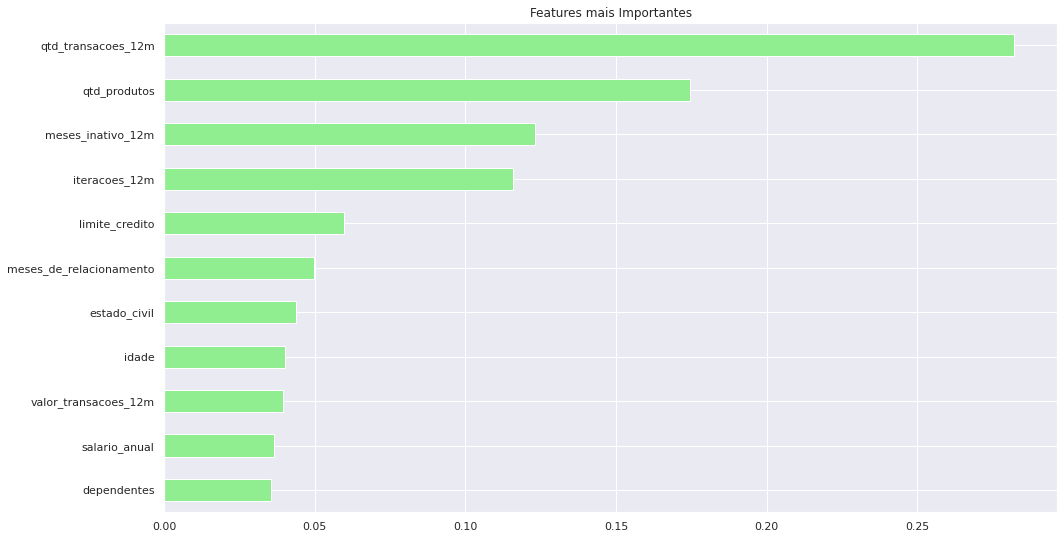

In [108]:
# Variáveis mais importantes com Árvore de Decisão
import matplotlib.pyplot as plt

# Cria uma serie de atributos mais importantes e ordena as séries
importances = pd.Series(data=clfAD2.feature_importances_, index= X_train.columns)
importances_sorted = importances.sort_values()

# Desenha um gráfico de barras
importances_sorted.plot(kind='barh', color='lightgreen')
plt.title('Features mais Importantes')
plt.show()